Q-1: Perché una predizione numerica vale molto di più di una direzionale?

Una predizione numerica è una predizione che ha come risultato un valore numerico preciso e quindi un valore atteso della variabile in questione. Una predizione direzionale, invece, è una predizione che ha come risultato la descrizione dell'andamento che avrà la variabile in questione, senza alcun riferimento numerico. Come si può notare già dalla tipologia delle due predizioni, quella numerica contiene intrinsecamente anche quella direzionale, poiché attraverso l'andamento numerico si può dedurre anche quello direzionale, per questo motivo la predizione numerica ha più valore rispetto a quella direzionale.

Q-2: Se il rango effettivo cala come previsto, questo dimostra che è il fine-tuning a causarlo? Quale controllo serve per escludere che sia il semplice addestramento supervisionato, a prescindere dal pre-addestramento?


Non è detto che la causa della diminuzione del rango sia dovuto al fine-tuning. Per testarlo basta effettuare il calcolo del rango nelle stesse condizioni, in un caso con il modello pre-addestrato e nell'altro cpartendo da zero. Se in entrambi i casi il rango diminuisce allora non si può attribuire la causa al fatto che sia stato fatto fine-tuning.



Q-3: Un revisore obietta: «il neural collapse è un fenomeno dei modelli sovraparametrizzati, il suo modello da 200k parametri non è nel
regime giusto». Prepari la risposta. Suggerimento: ciò che conta non è il numero assoluto di parametri ma la capacità di interpolare il
training set. Come lo verifica empiricamente?

Nonostante il Neural Collapse sia stato studiato soprattutto in modelli sovraparametrizzati, il numero di parametri non è una misura sufficiente per definire se un modello sia in grado o no di interpolare i dati di training. La cosa fondamentale resta verificare che il modello sia nel regime di interesse e che quindi riesca a raggiungere il 100% di training accuracy. La verifica empirica consiste nel raggiungere il 100% di accuratezza sul training set e successivamente, mentre il training continua dopo aver raggiunto l'accuratezza, si studiano le rappresentazioni per verificare la presenza di Neural Collapse.

E-1: generare 200 punti secondo
y = 3x+1+rumore e trovare la retta che meglio approssima quei punti usando la discesa del gradiente per la regressione lineare.

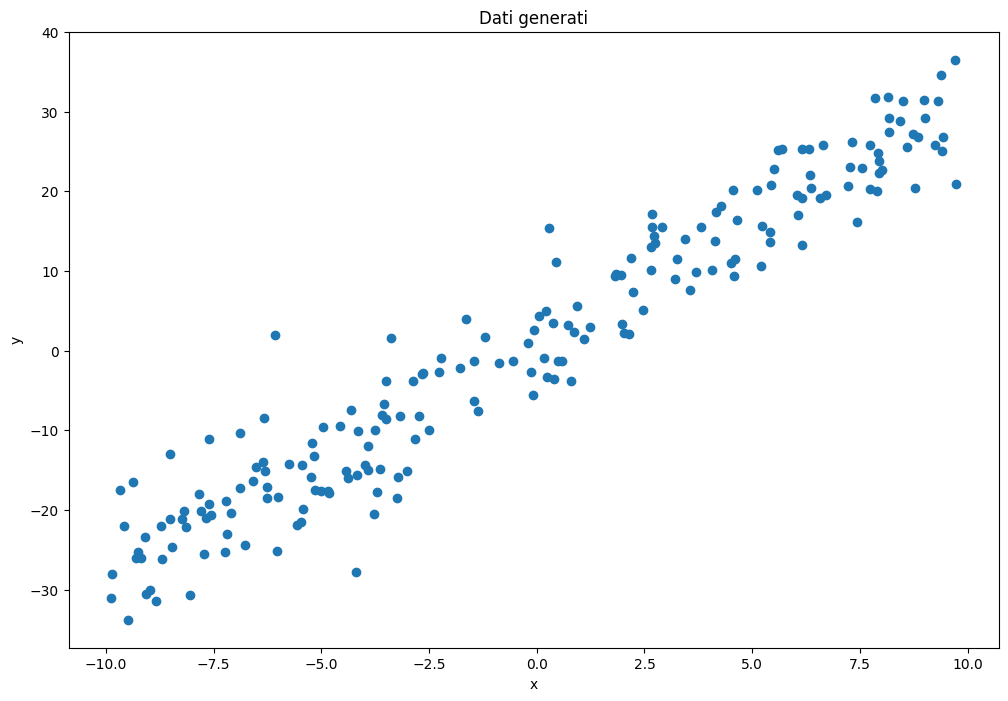

L'Errore Quadratico Medio (MSE) è: 330.9423362176781
L'Errore Quadratico Medio (MSE) è: 53.68489366263501
L'Errore Quadratico Medio (MSE) è: 27.714223636950248
L'Errore Quadratico Medio (MSE) è: 25.226910984060623
L'Errore Quadratico Medio (MSE) è: 24.936332854092857
L'Errore Quadratico Medio (MSE) è: 24.853319241263183
L'Errore Quadratico Medio (MSE) è: 24.791906439714438
L'Errore Quadratico Medio (MSE) è: 24.73463045877147
L'Errore Quadratico Medio (MSE) è: 24.6797757830975
L'Errore Quadratico Medio (MSE) è: 24.62710177657602
L'Errore Quadratico Medio (MSE) è: 24.576508791188836
L'Errore Quadratico Medio (MSE) è: 24.52791339965076
L'Errore Quadratico Medio (MSE) è: 24.48123661655597
L'Errore Quadratico Medio (MSE) è: 24.436402682203866
L'Errore Quadratico Medio (MSE) è: 24.3933388379896
L'Errore Quadratico Medio (MSE) è: 24.35197519882987
L'Errore Quadratico Medio (MSE) è: 24.312244638864193
L'Errore Quadratico Medio (MSE) è: 24.274082682438546
L'Errore Quadratico Medio (MSE) è: 24.2

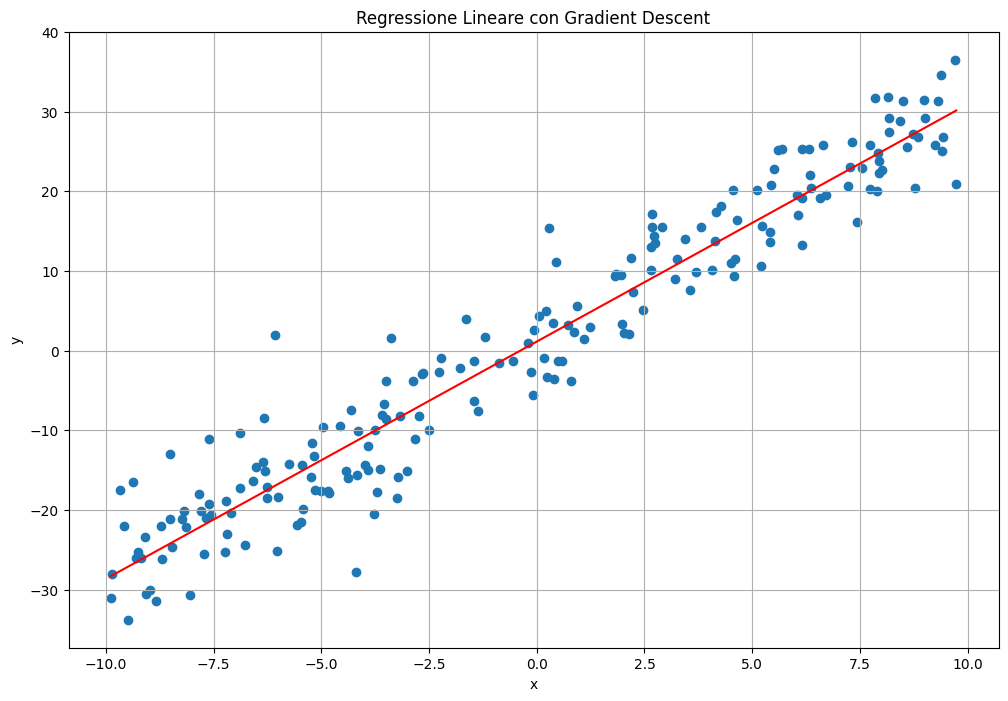

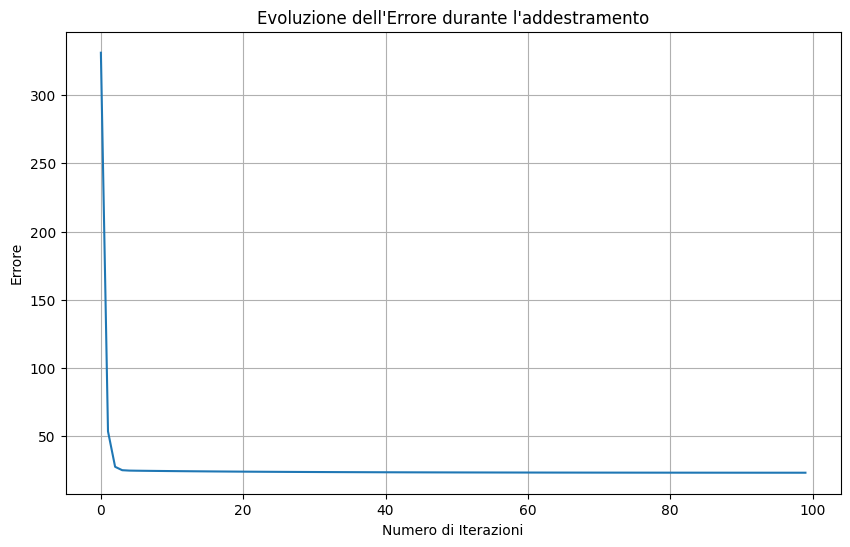

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#definizione del numero di elementi da generare
N = 200

#definisco il numero di iterazioni che desidero fare
iterazioni = 100

#inizializzo l'array di errori
errori = []

#generazione dei dati
np.random.seed(42)
x=np.random.uniform(-10,10,N)

#generazione del rumore
rumore=np.random.normal(loc=0, scale=5, size=N)

#trovo y
y=3*x+1+rumore

#visualizzazione dei dati
plt.figure(figsize=(12,8))
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dati generati')

plt.show()

#creo i parametri per il calcolo del gradiente
m = 0
q = 0

for i in range (iterazioni):
#calcolo la previsione della y
  predizione_y = m * x + q

#calcolo l'errore in base al valore previsto e il valore reale
  errore = predizione_y - y

#calcolo l'errore medio quadratico
  errore_quadratico = errore**2

#sommo tutti gli errori al quadrato
  somma_errori = np.sum(errore_quadratico)

#trovo l'MSE dividendo la somma per il numero di elementi N
  MSE = somma_errori / N

  print("L'Errore Quadratico Medio (MSE) è:",MSE)

#inserisco gli MSE negli array
  errori.append(MSE)

#trovo il gradiente calcolando prima la derivata rispetto a m e poi rispetto a q
  grad_m = (2/N) * np.sum(errore * x)
  grad_q = (2/N) * np.sum(errore)

#creo un learning rate
  learning_rate = 0.01

#aggiorno i parametri
  m = m - learning_rate * grad_m
  q = q - learning_rate * grad_q

#stampo  i valori di m e q
print("pendenza trovata: ", m)
print("intercetta trovata:",q)

#creo il grafico dei risultato
plt.figure(figsize=(12,8))
plt.scatter(x,y)
plt.plot([min(x),max(x)],[min(predizione_y),max(predizione_y)],color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione Lineare con Gradient Descent')
plt.grid(True)
plt.show()

#creo il grafico dell'errore con il numero di iterazioni
plt.figure(figsize=(10,6))
plt.plot(errori)
plt.xlabel('Numero di Iterazioni')
plt.ylabel('Errore')
plt.title('Evoluzione dell\'Errore durante l\'addestramento')
plt.grid(True)
plt.show()

